# Basic Analysis

Post-process the data ... Skip this if you already have the data post-processed.

In [ ]:
import json
from pathlib import Path


# Load abstracts and classifications
abstracts_file = Path("./abstracts.json")
taxonomy2_file = Path("./classified_abstracts_taxonomy2.json")
output_file = Path("./classified_abstracts_unified.json")

print("Loading data...")
with open(abstracts_file, 'r', encoding='utf-8') as f:
    abstracts = json.load(f)

with open(taxonomy2_file, 'r', encoding='utf-8') as f:
    classifications = json.load(f)

# Create title-to-classification mapping
title_to_classified = {}
for item in classifications:
    title = item.get('title', '')
    title_to_classified[title] = item

# Merge data
print(f"\nMerging {len(abstracts)} abstracts with classifications...")
merged = []
unmatched_titles = []

for abstract in abstracts:
    title = abstract.get('title', '')
    if title in title_to_classified:
        classified_item = title_to_classified[title]
        merged_item = {
            **abstract,
            'categories': classified_item.get('categories', []),
            'reason': classified_item.get('reason', '')
        }
        merged.append(merged_item)
    else:
        unmatched_titles.append(title)

# Report results
print(f"✓ Successfully merged {len(merged)} abstracts")
if unmatched_titles:
    print(f"\n⚠ WARNING: {len(unmatched_titles)} abstracts missing classifications:")
    for title in unmatched_titles[:10]:
        print(f"  - {title}")
    if len(unmatched_titles) > 10:
        print(f"  ... and {len(unmatched_titles) - 10} more")
else:
    print("✓ All abstracts have been classified")

# Save unified file
with open(output_file, 'w', encoding='utf-8') as f:
    json.dump(merged, f, indent=4, ensure_ascii=False)

print(f"\n✓ Unified file saved to {output_file}")


Loading data...

Merging 864 abstracts with classifications...
✓ Successfully merged 864 abstracts
✓ All abstracts have been classified

✓ Unified file saved to classified_abstracts_unified.json


Make sure both outputs files have the same number of samples and combine both datasets into a single dataframe for analysis ...

In [4]:
import json
from pathlib import Path
import pandas as pd

taxonomy1 = Path("./classified_abstracts_taxonomy1.json")
taxonomy2 = Path("./classified_abstracts_taxonomy2.json")

# Load both datasets
with open(taxonomy1, 'r', encoding='utf-8') as f:
    data1 = json.load(f)

with open(taxonomy2, 'r', encoding='utf-8') as f:
    data2 = json.load(f)

# Create dataframes and add taxonomy source column
df1 = pd.DataFrame(data1)
df1['taxonomy'] = 'taxonomy1'

df2 = pd.DataFrame(data2)
df2['taxonomy'] = 'taxonomy2'

# Combine datasets
combined_df = pd.concat([df1, df2], ignore_index=True)

print(f"Samples in taxonomy1: {len(df1)}")
print(f"Samples in taxonomy2: {len(df2)}")
print(f"Total combined samples: {len(combined_df)}")
print(f"\nTaxonomy distribution:")
print(combined_df['taxonomy'].value_counts())
combined_df.head()


Samples in taxonomy1: 864
Samples in taxonomy2: 864
Total combined samples: 1728

Taxonomy distribution:
taxonomy
taxonomy1    864
taxonomy2    864
Name: count, dtype: int64


,year,title,authors,doi,url,abstract,categories,reason,taxonomy
0,2020,A game-theoretic approach for the multi-object...,"Fatma Laidoui, Fatima Benbouzid-Si Tayeb, Mali...",10.1145/3341105.3375778,https://dblp.org/rec/conf/sac/LaidouiTBL20,This study proposes a novel game theory based ...,[Undefined],The paper focuses on a game-theoretic approach...,taxonomy1
1,2020,A Performance Analysis of Adaptive Streaming A...,"Carlos Renato Storck, Fátima de L. P. Duarte-F...",10.1109/ISCC50000.2020.9219682,https://dblp.org/rec/conf/iscc/StorckD20,Adaptive streaming is a technique used in mult...,[Undefined],The paper focuses on the performance analysis ...,taxonomy1
2,2020,A Vehicle-Centric Probabilistic Approach to Vi...,"Carlos Renato Storck, Guilherme G. de O. Silva...",10.1109/ISCC50000.2020.9219691,https://dblp.org/rec/conf/iscc/StorckSD20,The fifth generation (5G) cellular networks te...,[Undefined],The paper focuses on a technical approach to v...,taxonomy1
3,2020,The Effects of Heat Treatment on Fatigue Stren...,"Yushu Wang, Yikun Wang, Yicheng (Frederick) Jiang",10.1145/3421766.3421871,https://dblp.org/rec/conf/aiam/WangWJ20,"In this paper, the mechanical performance of w...",[Undefined],The paper focuses on mechanical performance an...,taxonomy1
4,2020,Exploring Visual Attention and Machine Learnin...,"Leonardo Souza Silva, Renull Vinicius Aranha, ...",10.1109/CBMS49503.2020.00035,https://dblp.org/rec/conf/cbms/SilvaARNM20,Temporal data visualization supports planning ...,[Undefined],The paper focuses on the application of visual...,taxonomy1


In [5]:
# Prepare category data for each taxonomy
results_by_taxonomy = {}

for tax in ['taxonomy1', 'taxonomy2']:
    df = combined_df[combined_df['taxonomy'] == tax]
    
    category_df = df[["year", "categories"]].explode("categories").rename(columns={"categories": "category"})
    category_df["category"] = category_df["category"].fillna("Undefined")
    category_df["year"] = pd.to_numeric(category_df["year"], errors="coerce")
    category_df = category_df.dropna(subset=["year"])
    category_df["year"] = category_df["year"].astype(int)
    
    category_counts = (
        category_df["category"]
        .value_counts()
        .rename_axis("category")
        .reset_index(name="count")
    )
    
    results_by_taxonomy[tax] = {
        'category_df': category_df,
        'category_counts': category_counts
    }

print("Taxonomy1 - Top 10 categories:")
print(results_by_taxonomy['taxonomy1']['category_counts'].head(10))
print("\nTaxonomy2 - Top 10 categories:")
print(results_by_taxonomy['taxonomy2']['category_counts'].head(10))


Taxonomy1 - Top 10 categories:
            category  count
0  Bias & Inequality    516
1          Undefined    273
2     Disempowerment    271
3   Authoritarianism     99
4         Robustness     74
5     Misinformation     55
6    Extinction Risk      2

Taxonomy2 - Top 10 categories:
             category  count
0   Bias & Inequality    452
1           Undefined    248
2              Safety    145
3        Transparency    139
4     Trustworthiness     91
5  Autonomy & Control     62
6             Privacy     61
7      Misinformation     54
8        Authenticity     31


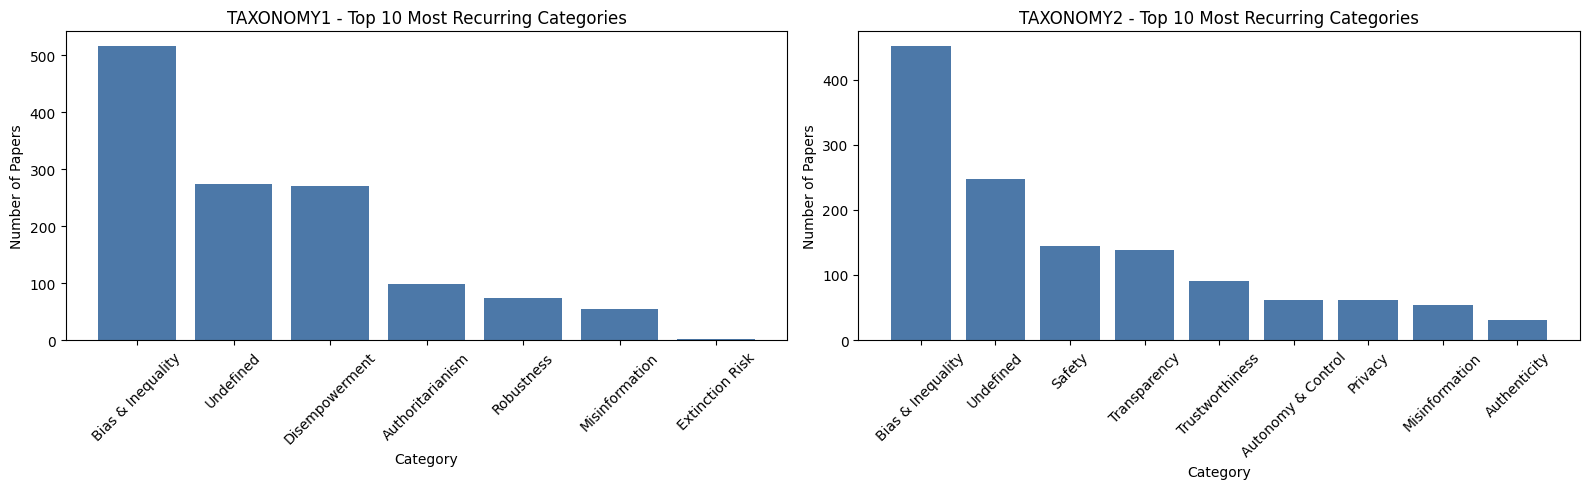

In [6]:
import matplotlib.pyplot as plt

top_n = 10

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for idx, tax in enumerate(['taxonomy1', 'taxonomy2']):
    plot_counts = results_by_taxonomy[tax]['category_counts'].head(top_n)
    
    axes[idx].bar(plot_counts["category"], plot_counts["count"], color="#4C78A8")
    axes[idx].set_title(f"{tax.upper()} - Top {top_n} Most Recurring Categories")
    axes[idx].set_xlabel("Category")
    axes[idx].set_ylabel("Number of Papers")
    axes[idx].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


In [7]:
# Get trend categories for each taxonomy
yearly_results = {}

for tax in ['taxonomy1', 'taxonomy2']:
    category_counts = results_by_taxonomy[tax]['category_counts']
    category_df = results_by_taxonomy[tax]['category_df']
    
    trend_categories = category_counts.loc[category_counts["category"] != "Undefined", "category"].head(6).tolist()
    if not trend_categories:
        trend_categories = category_counts.head(6)["category"].tolist()
    
    yearly_counts = (
        category_df[category_df["category"].isin(trend_categories)]
        .groupby(["year", "category"])
        .size()
        .unstack(fill_value=0)
        .sort_index()
    )
    
    yearly_results[tax] = yearly_counts
    print(f"\n{tax.upper()} - Yearly counts for top 6 categories:")
    print(yearly_counts)



TAXONOMY1 - Yearly counts for top 6 categories:
category  Authoritarianism  Bias & Inequality  Disempowerment  \
year                                                            
2020                     6                  9               7   
2021                    10                 68              34   
2022                    26                129              57   
2023                    25                127              63   
2024                    24                129              75   
2025                     8                 54              35   

category  Extinction Risk  Misinformation  Robustness  
year                                                   
2020                    0               5          16  
2021                    0               2           9  
2022                    1              15          16  
2023                    0               6           7  
2024                    1              17          17  
2025                    0             

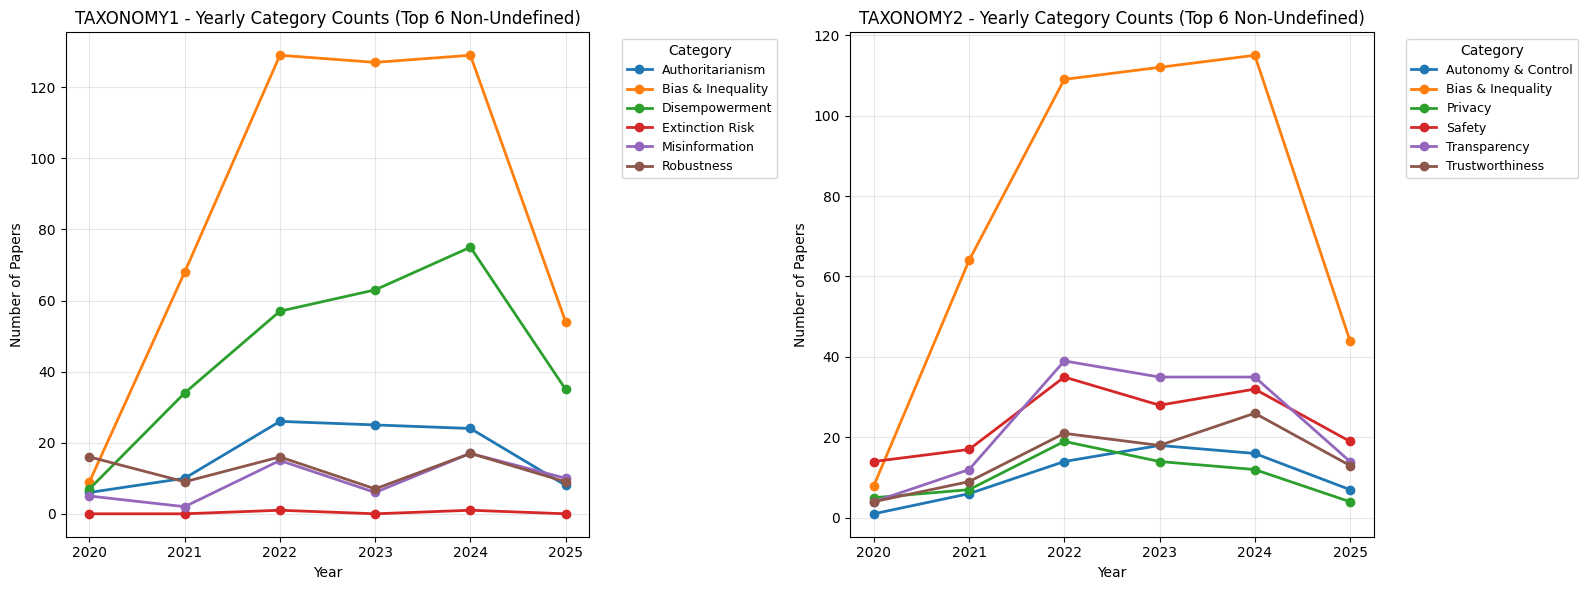

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, tax in enumerate(['taxonomy1', 'taxonomy2']):
    yearly_counts = yearly_results[tax]
    
    for category in yearly_counts.columns:
        axes[idx].plot(yearly_counts.index, yearly_counts[category], marker="o", linewidth=2, label=category)
    
    axes[idx].set_title(f"{tax.upper()} - Yearly Category Counts (Top 6 Non-Undefined)")
    axes[idx].set_xlabel("Year")
    axes[idx].set_ylabel("Number of Papers")
    axes[idx].legend(title="Category", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()
